# Spatial Transcriptomics Data IO using SpatialData

In [3]:
%pip install spatialdata-io spatialdata-plot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [spatialdata-plot]
Note: you may need to restart the kernel to use updated packages.


## Visium HD

### Download raw data

In [ ]:
!wget -P ./data/visiumhd https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Human_Colon_Cancer_P1/Visium_HD_Human_Colon_Cancer_P1_binned_outputs.tar.gz
!wget -P ./data/visiumhd https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Human_Colon_Cancer_P1/Visium_HD_Human_Colon_Cancer_P1_feature_slice.h5
!tar -xf ./data/visiumhd/Visium_HD_Human_Colon_Cancer_P1_binned_outputs.tar.gz -C ./data/visiumhd
!wget -P ./data/visiumhd https://zenodo.org/records/15042463/files/HumanColonCancer_VisiumHD-main.zip
!unzip ./data/visiumhd/HumanColonCancer_VisiumHD-main.zip -d ./data/visiumhd

--2025-07-22 23:48:29--  https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Human_Colon_Cancer_P1/Visium_HD_Human_Colon_Cancer_P1_binned_outputs.tar.gz
cf.10xgenomics.com (cf.10xgenomics.com) 해석 중... 104.18.1.173, 104.18.0.173, 2606:4700::6812:ad, ...
다음으로 연결 중: cf.10xgenomics.com (cf.10xgenomics.com)|104.18.1.173|:443... 연결했습니다.
HTTP 요청을 보냈습니다. 응답 기다리는 중... 200 OK
길이: 12319027011 (11G) [application/x-tar]
저장 위치: `./data/visiumhd/Visium_HD_Human_Colon_Cancer_P1_binned_outputs.tar.gz'

Visium_HD_Human_Col 100%[===================>]  11.47G  93.0MB/s    /  2m 6s   

2025-07-22 23:50:36 (93.3 MB/s) - `./data/visiumhd/Visium_HD_Human_Colon_Cancer_P1_binned_outputs.tar.gz' 저장함 [12319027011/12319027011]

--2025-07-22 23:50:36--  https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Human_Colon_Cancer_P1/Visium_HD_Human_Colon_Cancer_P1_feature_slice.h5
cf.10xgenomics.com (cf.10xgenomics.com) 해석 중... 104.18.1.173, 104.18.0.173, 2606:4700::6812:ad, ...
다음으로 연결 중: cf.10xgeno

## Load raw data using SpatialData

In [1]:
import spatialdata_io

# Not only VisiumHD, spatialdata_io also have other dedicated functions to load raw data from different platforms.
# See the documentation for more details: https://spatialdata.scverse.org/projects/io/en/latest/api.html

# This will take a while to run!
sdata = spatialdata_io.visium_hd(path='./data/visiumhd', load_all_images=False)
sdata

/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndat

SpatialData object
├── Images
│     ├── 'Visium_HD_Human_Colon_Cancer_P1_hires_image': DataArray[cyx] (3, 4961, 6000)
│     └── 'Visium_HD_Human_Colon_Cancer_P1_lowres_image': DataArray[cyx] (3, 496, 600)
├── Shapes
│     ├── 'Visium_HD_Human_Colon_Cancer_P1_square_002um': GeoDataFrame shape: (8115564, 1) (2D shapes)
│     ├── 'Visium_HD_Human_Colon_Cancer_P1_square_008um': GeoDataFrame shape: (507684, 1) (2D shapes)
│     └── 'Visium_HD_Human_Colon_Cancer_P1_square_016um': GeoDataFrame shape: (127809, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (8115564, 18085)
      ├── 'square_008um': AnnData (507684, 18085)
      └── 'square_016um': AnnData (127809, 18085)
with coordinate systems:
    ▸ 'Visium_HD_Human_Colon_Cancer_P1', with elements:
        Visium_HD_Human_Colon_Cancer_P1_hires_image (Images), Visium_HD_Human_Colon_Cancer_P1_lowres_image (Images), Visium_HD_Human_Colon_Cancer_P1_square_002um (Shapes), Visium_HD_Human_Colon_Cancer_P1_square_008um (Shapes), Visium_

In [20]:
import pandas as pd

# Load the annotation data
dr = pd.read_csv('./data/visiumhd/HumanColonCancer_VisiumHD-main/MetaData/DeconvolutionResults_P1CRC.csv.gz').set_index('barcode')

# Show the first few rows of the deconvolution results
dr.dropna(subset=["DeconvolutionLabel1", "DeconvolutionLabel2"], how="all").head(20)

/tmp/ipykernel_2407805/3415710312.py:4: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  dr = pd.read_csv('./data/visiumhd/HumanColonCancer_VisiumHD-main/MetaData/DeconvolutionResults_P1CRC.csv.gz').set_index('barcode')


,DeconvolutionClass,DeconvolutionLabel1,DeconvolutionLabel2
barcode,,,
s_008um_00000_00289-1,singlet,Tumor II,Mast
s_008um_00000_00290-1,singlet,Tumor II,Endothelial
s_008um_00000_00291-1,singlet,Tumor II,Proliferating Fibroblast
s_008um_00000_00292-1,singlet,Tumor II,Adipocyte
s_008um_00000_00293-1,singlet,Tumor II,Tumor V
s_008um_00000_00294-1,singlet,Tumor II,Tumor III
s_008um_00000_00295-1,singlet,Tumor II,Tumor V
s_008um_00000_00296-1,singlet,Tumor II,Tumor V
s_008um_00000_00297-1,singlet,Tumor II,Tumor III


In [23]:
adata = sdata.tables['square_008um']
adata.obs = adata.obs.merge(
    dr[['DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2']],
    left_index=True, right_index=True, how='left'
)
adata

AnnData object with n_obs × n_vars = 507684 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

/tmp/ipykernel_2407805/2077825984.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='DeconvolutionLabel1', spot_size=100)


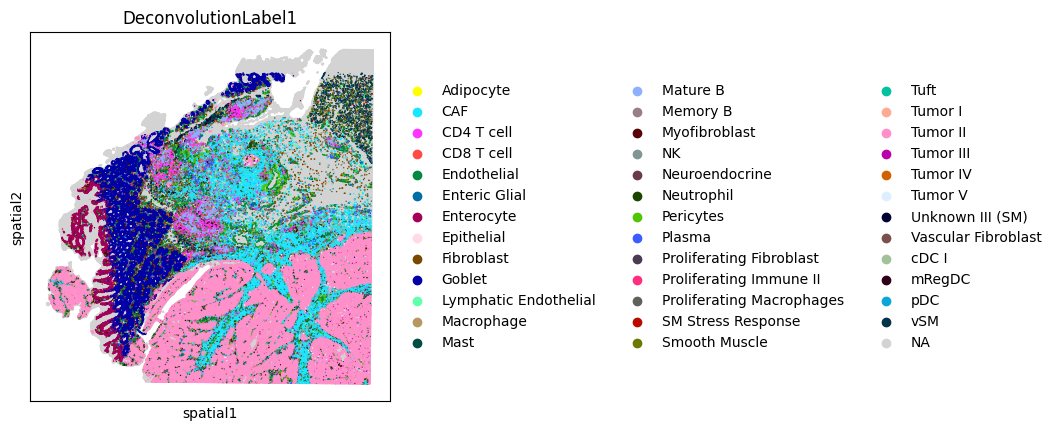

In [ ]:
import scanpy as sc
sc.pl.spatial(adata, color='DeconvolutionLabel1', spot_size=50)

In [ ]:
# replace the original adata with the cropped one
sdata.tables['square_008um'] = adata

/bce/groups/pnucolab/users/parkj/micromamba/envs/stlens/lib/python3.11/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `square_008um` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


In [29]:
bb_xmin, bb_ymin = 6000, 20000
bb_xmax, bb_ymax = 16000, 30000

cropped_sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="Visium_HD_Human_Colon_Cancer_P1",
)

cropped_sdata

SpatialData object
├── Images
│     ├── 'Visium_HD_Human_Colon_Cancer_P1_hires_image': DataArray[cyx] (3, 843, 844)
│     └── 'Visium_HD_Human_Colon_Cancer_P1_lowres_image': DataArray[cyx] (3, 84, 84)
├── Shapes
│     ├── 'Visium_HD_Human_Colon_Cancer_P1_square_002um': GeoDataFrame shape: (1849989, 1) (2D shapes)
│     ├── 'Visium_HD_Human_Colon_Cancer_P1_square_008um': GeoDataFrame shape: (116132, 1) (2D shapes)
│     └── 'Visium_HD_Human_Colon_Cancer_P1_square_016um': GeoDataFrame shape: (29232, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (1849989, 18085)
      ├── 'square_008um': AnnData (116132, 18085)
      └── 'square_016um': AnnData (29232, 18085)
with coordinate systems:
    ▸ 'Visium_HD_Human_Colon_Cancer_P1', with elements:
        Visium_HD_Human_Colon_Cancer_P1_hires_image (Images), Visium_HD_Human_Colon_Cancer_P1_lowres_image (Images), Visium_HD_Human_Colon_Cancer_P1_square_002um (Shapes), Visium_HD_Human_Colon_Cancer_P1_square_008um (Shapes), Visium_HD_Hum

In [31]:
cropped_sdata.tables['square_008um']

AnnData object with n_obs × n_vars = 116132 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'DeconvolutionClass', 'DeconvolutionLabel1', 'DeconvolutionLabel2'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs', 'DeconvolutionLabel1_colors'
    obsm: 'spatial'

/tmp/ipykernel_2407805/2552043370.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(cropped_sdata.tables['square_008um'], color="DeconvolutionLabel1", spot_size=50)


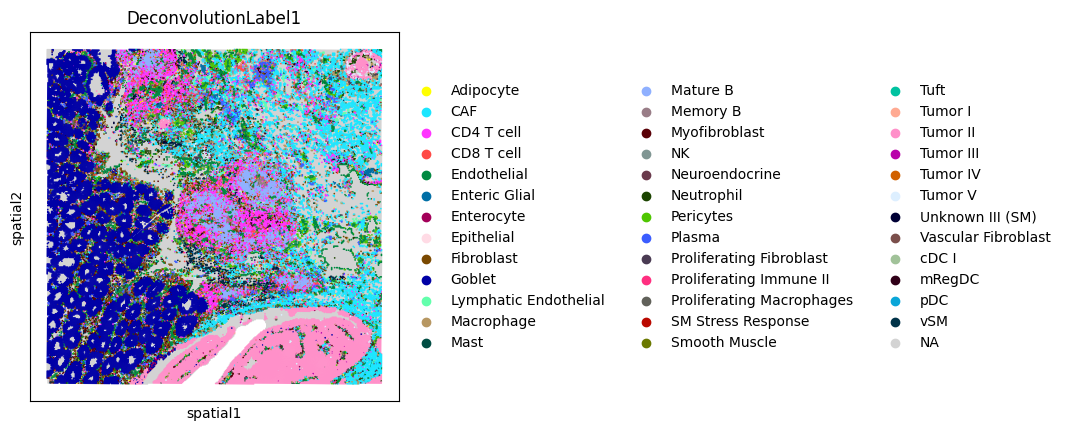

In [34]:
sc.pl.spatial(cropped_sdata.tables['square_008um'], color="DeconvolutionLabel1", spot_size=50)

In [ ]:
# Save the cropped data for later use
cropped_sdata.write('visiumhd_sdata_cropped.zarr')

INFO     The Zarr backing store has been changed from None the new file path: visiumhd_sdata_cropped.zarr          
